In [2]:
# Import required modules (nc_array_processing is an in-house DAS parallel processing code)
import numpy as np
import matplotlib.pyplot as plt
import nc_array_processing as dnc
import glob, os
from tqdm import tqdm
import h5py

test

Import the required modules (nc_array_processing is an in-house DAS processing software)

In [3]:
# Set number of processors
dnc.process.set_num_threads(80)

Set threads: 80 | PyTorch: 80 | Numba: 80


## Read in DAS data

In [4]:
#Can be used to pickle, read multiple DAS files at the same time
def readall(files):
    data = []
    for f in tqdm(files):
        arr=dnc.read.from_pickle(f)
        data.append(arr)
    return dnc.process.merge(data)

In [5]:
#Do a comparison, single 15 min DAS record, day v night
xsec_febus = dnc.read.vds('/mnt/geofib/1/2025-GRANGEGORMAN_NOISE/Virtual_Datasets/10-08_CH1_grangegorman.vds.h5',time=['2025-10-09T08:30:00.0000Z','2025-10-09T08:45:00.0000Z'],chan=[0,3125],model='febus')
xsec_febus_night = dnc.read.vds('/mnt/geofib/1/2025-GRANGEGORMAN_NOISE/Virtual_Datasets/10-08_CH1_grangegorman.vds.h5',time=['2025-10-09T02:00:00.0000Z','2025-10-09T02:15:00.0000Z'],chan=[0,3125],model='febus')

#---------------------------#
#- full VDS header
block_aware :  True
channels :  [   0 5211]
dt :  0.01
dx :  9.600000000000001
samples_per_block :  100
sampling_rate :  100.0
starttime :  2025-10-08T09:16:42.732540
 
#---------------------------#
#- requested chunk header
block_aware :  True
channels :  [0, 3125]
dt :  0.01
dx :  9.600000000000001
samples_per_block :  100
sampling_rate :  100.0
starttime :  2025-10-09T08:30:00.992540Z
time :  [0, 900.0]
#---------------------------#
#- full VDS header
block_aware :  True
channels :  [   0 5211]
dt :  0.01
dx :  9.600000000000001
samples_per_block :  100
sampling_rate :  100.0
starttime :  2025-10-08T09:16:42.732540
 
#---------------------------#
#- requested chunk header
block_aware :  True
channels :  [0, 3125]
dt :  0.01
dx :  9.600000000000001
samples_per_block :  100
sampling_rate :  100.0
starttime :  2025-10-09T02:00:00.712540Z
time :  [0, 900.0]


In [6]:
help(xsec_febus)
keys_list = list(xsec_febus.keys())
print(keys_list)

Help on dict object:

class dict(object)
 |  dict() -> new empty dictionary
 |  dict(mapping) -> new dictionary initialized from a mapping object's
 |      (key, value) pairs
 |  dict(iterable) -> new dictionary initialized as if via:
 |      d = {}
 |      for k, v in iterable:
 |          d[k] = v
 |  dict(**kwargs) -> new dictionary initialized with the name=value pairs
 |      in the keyword argument list.  For example:  dict(one=1, two=2)
 |  
 |  Built-in subclasses:
 |      StgDict
 |  
 |  Methods defined here:
 |  
 |  __contains__(self, key, /)
 |      True if the dictionary has the specified key, else False.
 |  
 |  __delitem__(self, key, /)
 |      Delete self[key].
 |  
 |  __eq__(self, value, /)
 |      Return self==value.
 |  
 |  __ge__(self, value, /)
 |      Return self>=value.
 |  
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |  
 |  __getitem__(...)
 |      x.__getitem__(y) <==> x[y]
 |  
 |  __gt__(self, value, /)
 |      Return self>va

In [7]:
#Placeholder/redundancy
xsec=xsec_febus

In [8]:
#Check data load was as desired
print(xsec)
print(xsec['data'].shape)

{'header': {'block_aware': np.True_, 'channels': [0, 3125], 'dt': np.float64(0.01), 'dx': np.float64(9.600000000000001), 'samples_per_block': np.int64(100), 'sampling_rate': np.float64(100.0), 'starttime': UTCDateTime(2025, 10, 9, 8, 30, 0, 992540), 'time': [0, 900.0]}, 'data': array([[  37.784317, -120.90923 ,  -28.695398, ...,  -51.076088,
         -75.9923  , -153.934   ],
       [-154.445   , -401.18906 , -336.45312 , ..., -228.19467 ,
         149.44116 ,  -16.231955],
       [ -96.77563 ,  -75.95861 , -248.2936  , ...,  257.3774  ,
         190.78459 ,  307.48126 ],
       ...,
       [ -82.80324 ,  -48.012142,   37.601936, ...,   66.40548 ,
         -93.19746 ,   64.985695],
       [  60.41979 ,  -55.983624,   24.208204, ...,   56.656162,
          86.33757 ,   21.871973],
       [ 150.42622 ,    8.603031,   58.66098 , ..., -192.01387 ,
          53.131283,  -47.405384]], shape=(3125, 90001), dtype=float32)}
(3125, 90001)


In [9]:
#Stacking redundancy
#xec_slice = dnc.process.stack_channels(xsec_slice,nchans=4,overlap=3)

In [10]:
#print(xsec_slice)
#print(xsec_slice['data'].shape)

## Pre-processing

In [11]:
#Demedian the records
xsec_rmed,med = dnc.process.remove_median(dnc.process.detrend(xsec_febus))
xsec_night_rmed,night_rmed= dnc.process.remove_median(dnc.process.detrend(xsec_febus_night))
print(xsec_rmed['data'].shape)

(3125, 90001)


In [12]:
#FK filter the DAS data to see which frequencies/ wavenumbers may/may not contain useable seismic signal for downstream processing (e.g. CCFs)
fk, freqs, k = dnc.process.fk_analysis(xsec_rmed)
fk_surface, mask = dnc.process.fk_filter(fk, freqs, k, vmin=400, vmax=2000)
xsec_surface = dnc.process.fk2array(fk_surface, xsec_rmed['header'])

In [13]:
#FK filter the DAS data to see which frequencies/ wavenumbers may/may not contain useable seismic signal for downstream processing (e.g. CCFs)- this time, for a night time section
fkN, freqsN, kN = dnc.process.fk_analysis(xsec_night_rmed)
fk_surfaceN, maskN = dnc.process.fk_filter(fkN, freqsN, kN, vmin=400, vmax=2000)
xsec_surfaceN = dnc.process.fk2array(fk_surfaceN, xsec_night_rmed['header'])

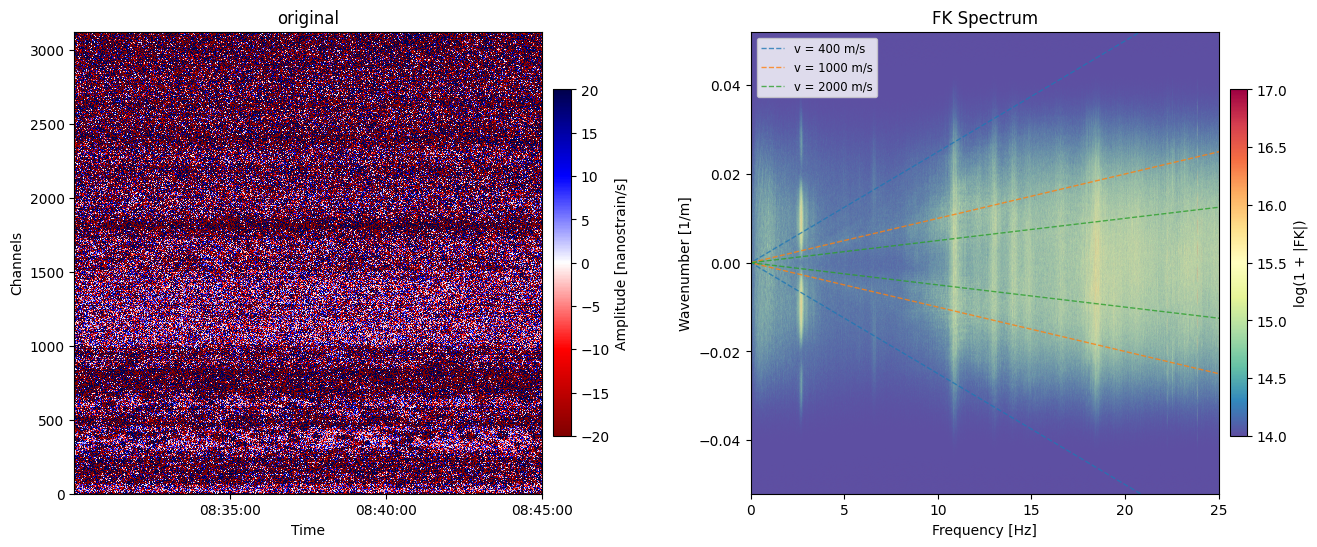

In [14]:
#FK Plot - not paper quality figure, for analysis purposes only
xsecs = [xsec_surface]
fks = [fk, fk_surface]
titles = ['original','velocity filtering body waves', 
          'velocity filtering surface waves',
          'velocity filtering only eastwards surface waves',
          'velocity filtering only westwards surface waves']

for i,x in enumerate(xsecs):
    
    fig,ax = plt.subplots(ncols=2,width_ratios=[1,1],figsize=[16,6])
    dnc.plot.plot_xsec(x,fast=True,sat=20,ax=ax[0],title=titles[i])
    dnc.plot.plot_fk(fks[i], freqs=freqs, wavenumbers=k, freq_lim=[0,25],ax=ax[1],amp_lim=(14, 17),velocities=[400,1000,2000])
    plt.savefig('FK_daytime_example.pdf',dpi=300)
    plt.show()  

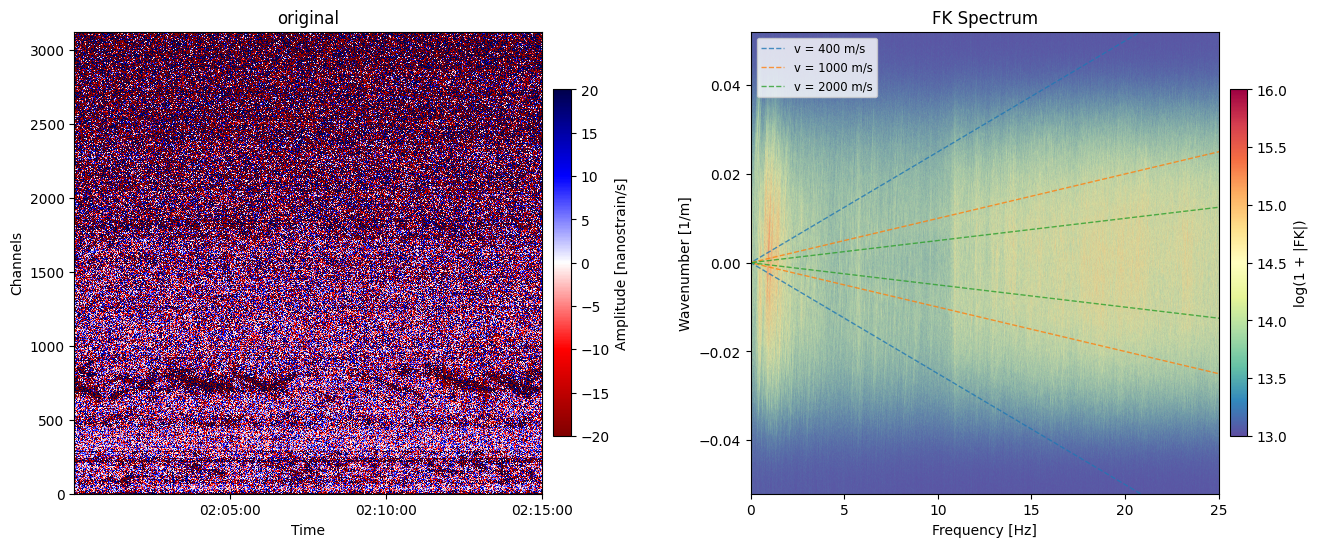

In [15]:
#FK Plot - not paper quality figure, for analysis purposes only - night time comparison
xsecsN = [xsec_surfaceN]
fksN = [fkN, fk_surfaceN]
titles = ['original','velocity filtering body waves', 
          'velocity filtering surface waves',
          'velocity filtering only eastwards surface waves',
          'velocity filtering only westwards surface waves']

for i,x in enumerate(xsecsN):
    
    fig,ax = plt.subplots(ncols=2,width_ratios=[1,1],figsize=[16,6])
    dnc.plot.plot_xsec(x,fast=True,sat=20,ax=ax[0],title=titles[i])
    dnc.plot.plot_fk(fksN[i], freqs=freqsN, wavenumbers=k, freq_lim=[0,25],ax=ax[1],amp_lim=(13, 16),velocities=[400,1000,2000])
    plt.savefig('FK_night_example.pdf',dpi=300)
    plt.show()  

In [16]:
help(dnc.plot.plot_fk)

Help on function plot_fk in module nc_array_processing.plot:

plot_fk(fk, freqs, wavenumbers, figsize=(6, 5), velocities=None, freq_lim=None, amp_lim=None, k_lim=None, vel_unit='m/s', title='FK Spectrum', interp='bilinear', cmap='Spectral_r', ax=None, cbar_label=None, cbar_kwargs=None)
    Plot frequency-wavenumber (FK) spectrum.
    
    Parameters
    ----------
    fk : ndarray (complex)
        FK spectrum from fk_analysis().
    freqs : ndarray
        Frequency bins from fk_analysis().
    wavenumbers : ndarray
        Wavenumber bins from fk_analysis().
    figsize : tuple, default (6, 5)
        Figure size (width, height) in inches.
    velocities : list of float, optional
        Velocities (in vel_unit) to overlay as cone lines.
    freq_lim : tuple, optional
        Frequency limits (min, max) in Hz.
    amp_lim : tuple, optional
        Amplitude limits (vmin, vmax) for colormap.
    k_lim : tuple, optional
        Wavenumber limits (min, max) in 1/m.
    vel_unit : {'m/s'

In [17]:
## Calculate PSDs

In [18]:
#Psd daytime data
psd_febus, frequencies_febus = dnc.process.psd(xsec_rmed)
print(psd_febus.shape, frequencies_febus.shape)

(3125, 45000) (45000,)


In [19]:
#Psd night time data
psd_febusNight, frequencies_febusNight = dnc.process.psd(xsec_night_rmed)
print(psd_febusNight.shape)

(3125, 45000)


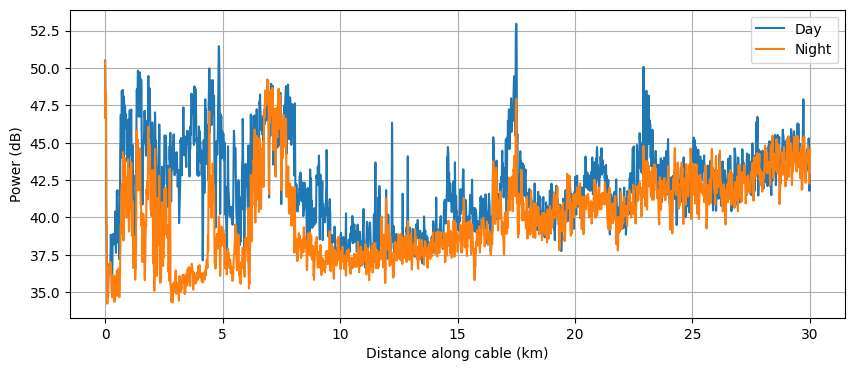

In [20]:
# 1. Sum across all frequency bins for each channel - i.e. distance-based PSD

channel_power = np.mean(psd_febus, axis=1) 
night_channel_power=np.mean(psd_febusNight,axis=1)

if channel_power.shape[0] != 3125:
    channel_power = np.mean(psd_febus, axis=0)
if night_channel_power.shape[0] != 3125:
    night_channel_power=np.mean(psd_febusNight, axis=0)

# 2. Convert to dB
channel_db = 10 * np.log10(channel_power)
channel_db_Night = 10 * np.log10(night_channel_power)

# 3. Create distance axis (e.g., if channels are 2m apart)
dx = 9.6 
distance = np.arange(3125) * (dx/1000)

# 4. Plot
plt.figure(figsize=(10, 4))
plt.plot(distance, channel_db, label='Day')
plt.plot(distance, channel_db_Night, label='Night')
plt.xlabel("Distance along cable (km)")
plt.ylabel("Power (dB)")
#plt.title("Total Acoustic Power vs. Distance")
plt.grid(True)
plt.legend(loc='best')
plt.savefig('./PSD_day_v_night_distance.png',dpi=300)
plt.show()

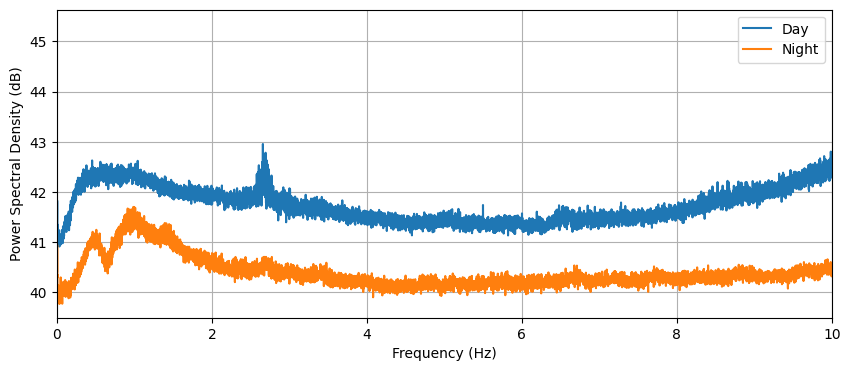

In [21]:
#Frequency-wise PSD - all channels

# 1. Average across the channel/distance axis (axis=0)
freq_power = np.mean(psd_febus, axis=0)
freq_power_night = np.mean(psd_febusNight, axis=0)

# CHECK: Ensure the output matches the number of frequency bins
if freq_power.shape[0] != frequencies_febus.shape[0]:
    # If it swapped, average across axis=1 instead
    freq_power = np.mean(psd_febus, axis=1)
    freq_power_night = np.mean(psd_febusNight, axis=1)

# 2. Convert to dB
freq_db = 10 * np.log10(freq_power)
freq_db_night = 10 * np.log10(freq_power_night)

# 3. Plot using your existing frequencies_febus vector
plt.figure(figsize=(10, 4))
plt.plot(frequencies_febus, freq_db, label="Day")
plt.plot(frequencies_febus, freq_db_night, label="Night")
plt.xlabel("Frequency (Hz)")
plt.xlim([0,10])
plt.ylabel("Power Spectral Density (dB)")
plt.grid(True)
plt.legend(loc="best")
plt.savefig("./PSD_day_v_night_frequency_zoom.png", dpi=300)
plt.show()


In [22]:
num_points = distance.shape[0]
distance_2d = distance[np.newaxis, :]
channel_db_2d = channel_db[np.newaxis, :]
my_label='placeholder'

with h5py.File('./psd_hdf5_outs/grangegorman_psds_15min_chunks.h5', 'w') as f:
    # Write in a way that the hdf5 can be added to/appended
    f.create_dataset(
        'distance', 
        shape=(1, num_points),
        maxshape=(None, num_points), # Allows infinite rows of distance curves
        chunks=(1, num_points),
        dtype='float32',
        compression='gzip'
    )
    
    # Ditto
    f.create_dataset(
        'channel_db', 
        shape=(1, num_points),
        maxshape=(None, num_points), # Allows infinite rows of dB curves
        chunks=(1, num_points),
        dtype='float32',
        compression='gzip'
    )

    str_type = h5py.string_dtype(encoding='utf-8')
    f.create_dataset(
        'labels', 
        shape=(1,), 
        maxshape=(None,), 
        dtype=str_type
    )
    
    #Write to file
    f['distance'][0, :] = distance_2d
    f['channel_db'][0, :] = channel_db_2d
    f['labels'][0] = my_label
    
    # Store your static system metadata
    f.attrs['gauge_length_m'] = 10.0
    f.attrs['spatial_sampling_m'] = 9.6

 Reloaded values match original data exactly!


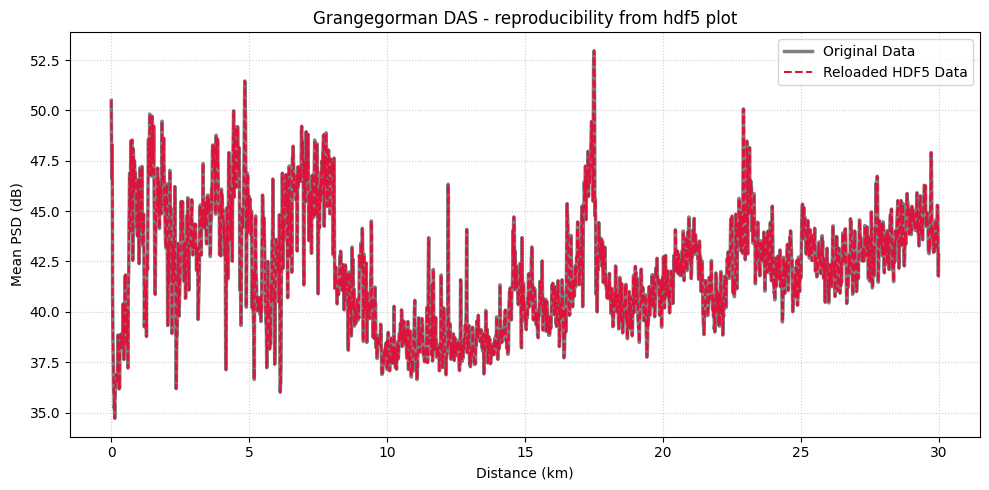

In [23]:

# Check PSDs can be re-produced from the hdf5
file_path = './psd_hdf5_outs/grangegorman_psds_15min_chunks.h5'

with h5py.File(file_path, 'r') as f:
    # Pull out the first row (index 0) where we saved the 1D arrays
    reloaded_distance = f['distance'][0, :]
    reloaded_channel_db = f['channel_db'][0, :]
    
    # Reload metadata for verification
    gl = f.attrs['gauge_length_m']
    dx = f.attrs['spatial_sampling_m']

# Verify match
dist_match = np.allclose(reloaded_distance, distance, rtol=1e-5, atol=1e-8)
db_match = np.allclose(reloaded_channel_db, channel_db, rtol=1e-5, atol=1e-8)

if dist_match and db_match:
    print(" Reloaded values match original data exactly!")
else:
    print("QUANTITATIVE CHECK FAILED: Value mismatch detected.")
    if not dist_match:
        print(f"Max distance difference: {np.max(np.abs(reloaded_distance - distance))}")
    if not db_match:
        print(f"Max dB difference: {np.max(np.abs(reloaded_channel_db - channel_db))}")


# Plot for comparison
plt.figure(figsize=(10, 5))

# original daytime psd
plt.plot(distance, channel_db, 
         label='Original Data', color='black', alpha=0.5, linewidth=2.5)

# Plot reloaded HDF5 data
plt.plot(reloaded_distance, reloaded_channel_db, 
         label='Reloaded HDF5 Data', color='crimson', linestyle='--', linewidth=1.5)

# Formatting labels
plt.title(f'Grangegorman DAS - reproducibility from hdf5 plot')
plt.xlabel('Distance (km)')
plt.ylabel('Mean PSD (dB)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Show the clean plot
plt.tight_layout()
plt.show()


In [24]:
#Ibid - PSD vs frequency